# Don't Bet on the Super Bowl

This notebook contains a supporting example for [Think Stats 3e](https://allendowney.github.io/ThinkStats/).

*Think Stats* is available now from [Bookshop.org](https://bookshop.org/a/98697/9781098190255) and [Amazon](https://amzn.to/42lmxwu) (affiliate links). If you are enjoying the free, online version, please consider [buying me a coffee](https://buymeacoffee.com/allendowney).

[Click here to run this notebook on Colab](https://colab.research.google.com/github/AllenDowney/ThinkStats/blob/v3/examples/[notebook_name].ipynb)

In [43]:
import os
import urllib.request
import urllib.parse

def download(url):
    filename = os.path.basename(urllib.parse.unquote(url))
    if not os.path.exists(filename):
        urllib.request.urlretrieve(url, filename)
        print("Downloaded " + filename)


download("https://github.com/AllenDowney/ThinkStats/raw/v3/nb/thinkstats.py")

In [44]:
try:
    import empiricaldist
except ImportError:
    !pip install empiricaldist

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from thinkstats import decorate

If you have studied probability, you might be familiar with fractional odds, which represent the ratio of the probability something happens to the probability it doesn't.
For example, if the Seahawks have a 75% chance of winning the Super Bowl, they have a 25% chance of losing, so the ratio is 75 to 25, sometimes written 3:1 and pronounced "three to one".

But if you search for "the odds that the Seahawks win", you will probably get **moneyline odds**, also known as American odds.
Right now, the moneyline odds are -240 for the Seahawks and +195 for the Patriots.
If you are not familiar with this format, that means:

* If you bet `$100` on the Patriots and they win, you gain `$195` -- otherwise you lose `$100`.

* If you bet `$240` on the Seahawks and they win, you gain `$100` -- otherwise you lose `$240`.

If you are used to fractional odds, this format might make your head hurt.
So let's unpack it.

Suppose you think the Patriots have a 25% chance of winning.
Under that assumption, we can compute the expected value of the first wager like this:

In [46]:
def expected_value(p, wager, payout):
    return p * payout - (1-p) * wager

In [47]:
expected_value(p=0.25, wager=100, payout=195)

-26.25

If the Patriots actually have a 25% chance of winning, the first wager has negative expected value -- so you probably don't want to make it.

Now let's compute the expected value of the second wager -- assuming the Seahawks have a 75% chance of winning:

In [48]:
expected_value(p=0.75, wager=240, payout=100)

15.0

The expected value of this wager is positive, so you might want to make it -- but only if you have good reason to think the Seahawks have a 75% chance of winning.

## Implied Probability

More generally, we can compute the expected value of each wager for a range of probabilities from 0 to 1.

In [49]:
ps = np.linspace(0, 1)
ev_patriots = expected_value(ps, 100, 195)

In [50]:
ps = np.linspace(0, 1)
ev_seahawks = expected_value(1-ps, 240, 100)

Here's what they look like.

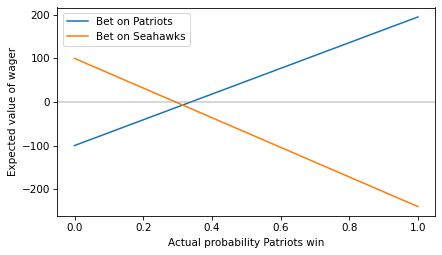

In [51]:
plt.plot(ps, ev_patriots, label='Bet on Patriots')
plt.plot(ps, ev_seahawks, label='Bet on Seahawks')
plt.axhline(0, color='gray', alpha=0.4)

decorate(xlabel='Actual probability Patriots win',
        ylabel='Expected value of wager')

To find the crossover point, we can set the expected value to `0` and solve for `p`.
This function computes the result:

In [52]:
def crossover(wager, payout):
    return wager / (wager + payout)

Here's crossover for a bet on the Patriots at the offered odds.

In [53]:
p1 = crossover(100, 195)
p1

0.3389830508474576

If you think the Patriots have a probability higher than the crossover, the first bet has positive expected value.

And here's the crossover for a bet on the Seahawks.

In [54]:
p2 = crossover(240, 100)
p2

0.7058823529411765

If you think the Seahawks have a probability higher than this crossover, the second bet has positive expected value.

So the offered odds imply that the consensus view of the betting market is that the Patriots have a 33.9% chance of winning and the Seahawks have a 70.6% chance.
But you might notice that the sum of those probabilities exceeds 1.

In [55]:
p1 + p2

1.0448654037886342

What does that mean?

## The Take

The sum of the crossover probabilities determines "the take", which is the share of the betting pool taken by "the house" -- that is, the entity that takes the bets.

For example, suppose 1000 people take the first wager and bet `$100` each on the Patriots.
And 1000 people take the second wager and bet `$240` on the Seahawks.

Here's the total expected value of all of those wagers.

In [56]:
total = expected_value(ps, 100_000, 195_000) + expected_value(1-ps, 240_000, 100_000) 

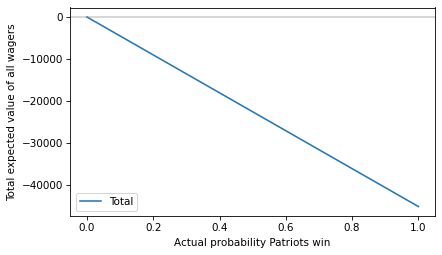

In [57]:
plt.plot(ps, total, label='Total')
plt.axhline(0, color='gray', alpha=0.4)

decorate(xlabel='Actual probability Patriots win',
        ylabel='Total expected value of all wagers')

The total expected value is negative for all probabilities (or zero if the Patriots have no chance at all) -- which means the house wins.

How much the house wins depends on the actual probability.
As an example, suppose the actual probability is the midpoint of the probabilities implied by the odds:


In [58]:
p = (p1 + (1-p2)) / 2
p

0.31655034895314055

In that case, here's the expected take, assuming that the implied probability is correct.

In [59]:
take = -expected_value(p, 100_000, 195_000) - expected_value(1-p, 240_000, 100_000) 
take

14244.765702891316

As a percentage of the total betting pool, it's a little more than 4%.

In [60]:
take / (100_000 + 240_000)

0.04189636971438623

Which we could have approximated by computing the "overround", which is the amount that the sum of the implied probabilities exceeds 1.

In [61]:
(p1 + p2) - 1

0.04486540378863424

## Don't Bet

In summary, here are the reasons you should not bet on the Super Bowl:

* If the implied probabilities are right (within a few percent) all wagers have negative expected value.

* If you think the implied probabilities are wrong, you might be able to make a good bet -- but only if you are right. The odds represent the aggregated knowledge of everyone who places a bet, which probably includes a lot of people who know more than you.

* If you spend a lot of time and effort, you might find instances where the implied probabilities are wrong, and you might even make money in the long run. But there are better things you could do with your time.

Betting is a zero-sum game if you include the house and a negative-sum game for people who bet.
If you make money, someone else loses -- there is no net creation of economic value.

So, if you have the skills to beat the odds, find something more productive to do.

[Think Stats: Exploratory Data Analysis in Python, 3rd Edition](https://allendowney.github.io/ThinkStats/index.html)

Copyright 2024 [Allen B. Downey](https://allendowney.com)

Code license: [MIT License](https://mit-license.org/)

Text license: [Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International](https://creativecommons.org/licenses/by-nc-sa/4.0/)
